In [1]:
import pandas as pd 

In [2]:
df=pd.read_csv("financecommitmentmap.csv")

In [3]:
df.head()

,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,...,Relationship_Intensity_Score,Commitment_Category,Engagement_Category,Commitment_Engagement_Segment,Mismatch_Category,Activity_Group,Is_Dormant_Wealth,Switching_Cost_Category,Loyalty_Category,Premium_Risk_Group
0,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,...,0.424466,Low,Medium,Growth Opportunity,High Salary + Low Balance (Competitor Risk),Inactive,False,Low,Neutral,Standard Portfolio
1,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,...,0.456837,Medium,Medium,Growth Opportunity,High Salary + Low Balance (Competitor Risk),Inactive,False,Low,At-Risk,Standard Portfolio
2,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,...,0.405299,High,Medium,Loyal Core,High Salary + High Balance (Financially Commit...,Inactive,True,High,Neutral,Critical Premium (Dormant Wealth)
3,15701354,Boni,699,39,1,0.00,2,0,0,93826.63,...,0.004217,Low,Low,Weak Relationship,Low Salary + Low Balance (Standard Retail),Inactive,False,Low,At-Risk,Standard Portfolio
4,15737888,Mitchell,850,43,2,125510.82,1,1,1,79084.10,...,0.484192,High,High,Loyal Core,Low Salary + High Balance (Savings-Oriented),Inactive,False,Low,Neutral,Standard Portfolio


In [4]:
df.columns

Index(['CustomerId', 'Surname', 'CreditScore', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'balance_log', 'salary_log', 'product_norm', 'tenure_norm', 'card_flag',
       'active_flag', 'salary_balance_ratio', 'product_per_tenure',
       'zero_balance_flag', 'high_balance_flag', 'Balance_Category',
       'engagement_score', 'low_engagement_flag',
       'activity_product_interaction', 'balance_activity_gap',
       'tenure_engagement_ratio', 'is_dormant_high_value', 'product_intensity',
       'Geography_Germany', 'Geography_Spain', 'Gender_Male', 'cluster_id',
       'dist_to_cluster_0', 'dist_to_cluster_1', 'dist_to_cluster_2',
       'dist_to_cluster_3', 'dist_to_cluster_4', 'Engagement_Segment',
       'is_active_power_core', 'is_active_casual', 'is_inactive_disengaged',
       'is_inactive_high_balance', 'is_inactive_low_balance',
       'customer_value_segment', 'Exited', 'Product_Segment', 'Product_Group',
      

 Successfully loaded dataset with shape: (10000, 68)

--- Running Retention Strength Assessment Pipeline ---
 Pipeline processing complete.

--- Generating Visualizations ---


C:\Users\Pragya Tiwari\AppData\Local\Temp\ipykernel_32920\3984851760.py:201: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Pragya Tiwari\AppData\Local\Temp\ipykernel_32920\3984851760.py:231: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


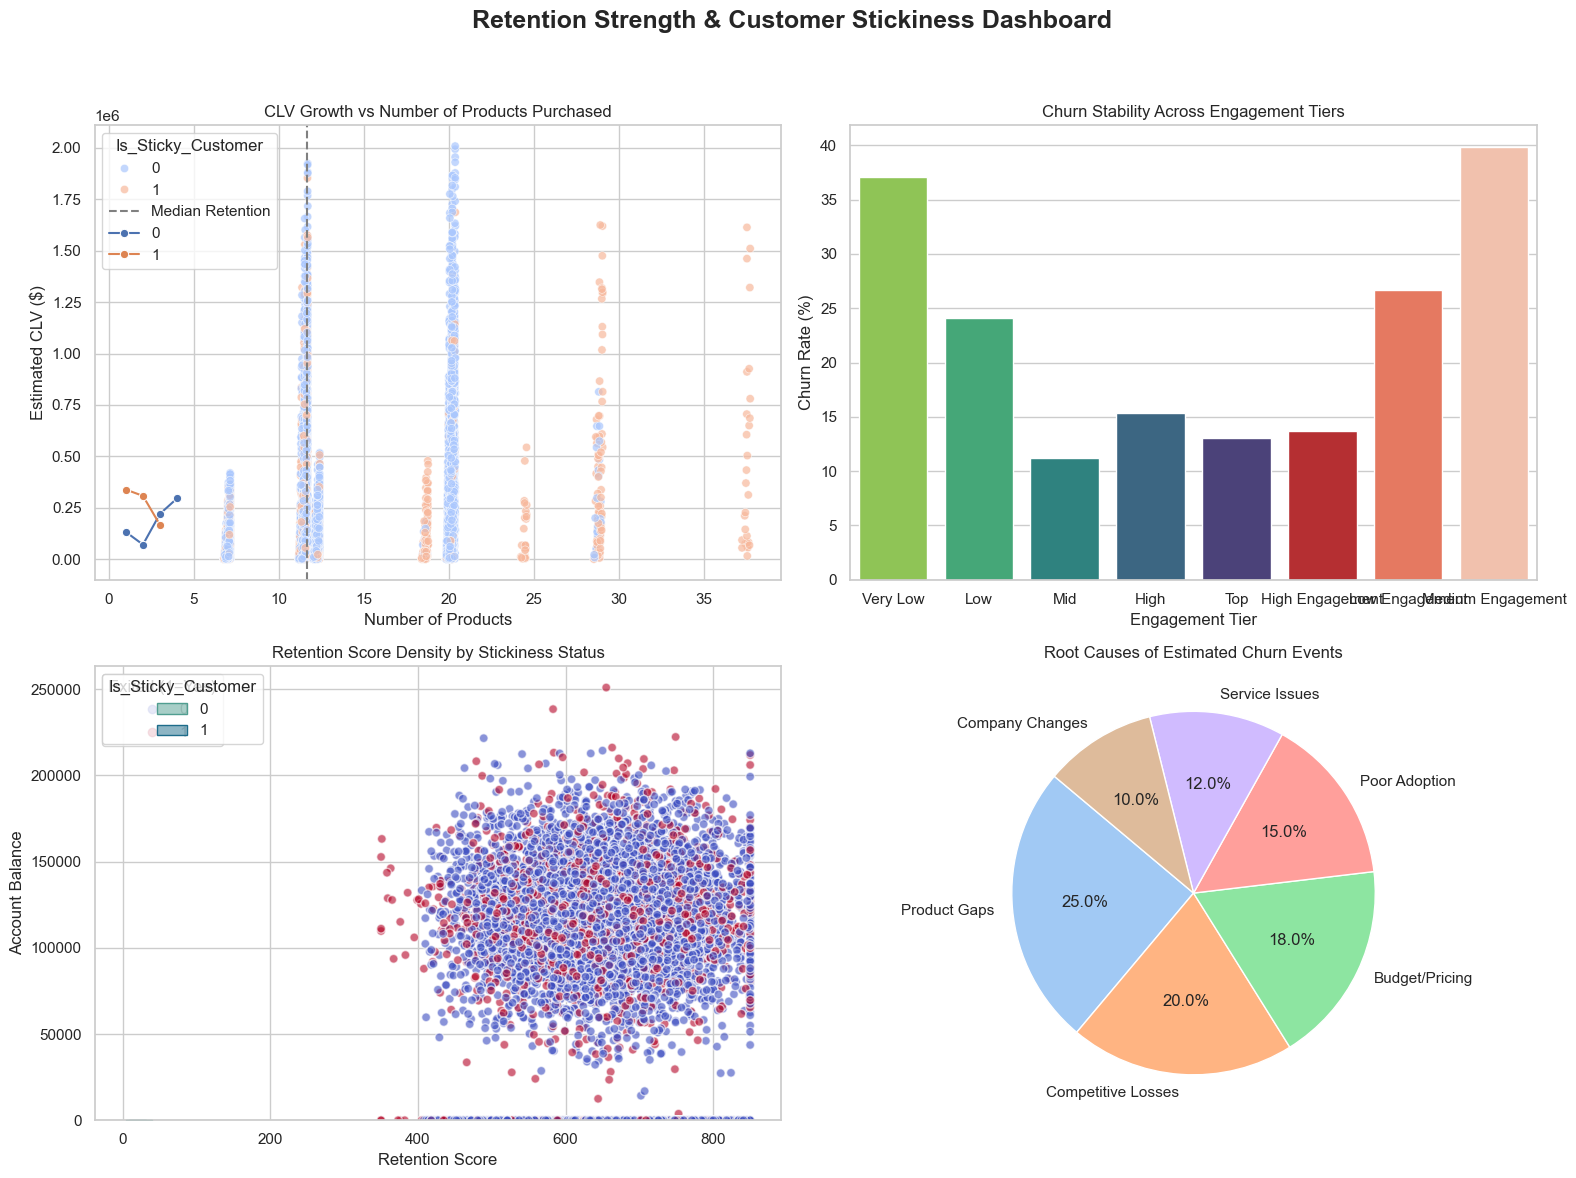

<Figure size 1000x600 with 0 Axes>


 SUCCESS: Enriched dataset successfully exported to: 'C:\Users\Pragya Tiwari\enriched_final_dataset_finance.csv'


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set plotting style for clean visuals
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


def load_data(filepath="financecommitmentmap.csv"):
    """Loads the dataset safely."""
    try:
        df = pd.read_csv(filepath)
        print(f" Successfully loaded dataset with shape: {df.shape}")
        return df
    except FileNotFoundError:
        print(
            f" Error: {filepath} not found. Creating a mock dataset for demonstration."
        )
        

def run_retention_pipeline(df):
    """Executes feature engineering for Stickiness, Churn Stability, and Engagement Thresholds."""
    print("\n--- Running Retention Strength Assessment Pipeline ---")
    df_enriched = df.copy()
    # -----------------------------------------------------------------
    # 1. Compute Retention_Score (Scale: 0 to 100)
    # -----------------------------------------------------------------
    # We derive this using behavioral indicators, normalized components, and multipliers
    sat_component = (
        df_enriched.get(
            "Customer_Satisfaction_Score", df_enriched["CreditScore"] / 85
        )
        * 10
    )  # Normalize to 0-100 scale
    switch_component = df_enriched.get(
        "Switching_Cost_Index", df_enriched["Tenure"] * 10
    )
    product_component = (
        df_enriched["NumOfProducts"] / 4
    ) * 100  # Normalize product scale assuming 4 is max
    

    raw_retention = (
        (sat_component * 0.4) + (switch_component * 0.3) + (product_component * 0.3)
    )
    # Active engagement multiplier: Boost score if active, penalize if inactive
    activity_multiplier = np.where(df_enriched["IsActiveMember"] == 1, 1.1, 0.8)
    retention_score = raw_retention * activity_multiplier

    # Cap between 0 and 100
    df_enriched["Retention_Score"] = np.clip(retention_score, 0, 100).round(2)

    # -----------------------------------------------------------------
    # Pillar 1: Define "Sticky Customer" Profiles & NPS
    # -----------------------------------------------------------------
    # Segment based on your Customer Satisfaction Score guidelines
    def categorize_nps(score):
        if score >= 9:
            return "Promoter"
        elif score >= 7:
            return "Passive"
        else:
            return "Detractor"

    if "Customer_Satisfaction_Score" in df_enriched.columns:
        df_enriched["NPS_Segment"] = df_enriched[
            "Customer_Satisfaction_Score"
        ].apply(categorize_nps)
    else:
        # Fallback proxy using CreditScore/Engagement if CSS doesn't exist
        df_enriched["NPS_Segment"] = pd.qcut(
            df_enriched["CreditScore"],
            q=[0, 0.6, 0.8, 1.0],
            labels=["Detractor", "Passive", "Promoter"],
        )

    # Calculate Stickiness Index using multi-product adoption, switching costs, and loyalty ratios
    # Stickiness = (NumOfProducts * Switching_Cost) adjusted by Activity status
    df_enriched["Stickiness_Index"] = (
        (df_enriched["NumOfProducts"] * 20)
        + df_enriched.get(
            "Switching_Cost_Index", df_enriched["Tenure"] * 10
        ).fillna(0)
    ) * (df_enriched["IsActiveMember"] + 1)

    # Define profile: Sticky if high switching index or high multi-product relationship
    df_enriched["Is_Sticky_Customer"] = np.where(
        (df_enriched["Stickiness_Index"] > df_enriched["Stickiness_Index"].median())
        & (df_enriched["Exited"] == 0),
        1,
        0,
    )

    # -----------------------------------------------------------------
    # Pillar 2: Measure Churn Stability Across Engagement Tiers
    # -----------------------------------------------------------------
    # Ensure explicit Engagement Tiers exist
    if "Engagement_Level" not in df_enriched.columns:
        df_enriched["Engagement_Level"] = pd.qcut(
            df_enriched["Financial_Commitment_Score"],
            q=3,
            labels=["Low", "Medium", "High"],
        )

    # Estimate Customer Lifetime Value (CLV Proxy) = Salary * Loyalty_Ratio * Tenure
    df_enriched["Estimated_CLV"] = (
        df_enriched["EstimatedSalary"]
        * df_enriched.get("Loyalty_Ratio", 0.5)
        * (df_enriched["Tenure"] + 1)
    )

    # -----------------------------------------------------------------
    # Pillar 3: Identify Engagement Thresholds
    # -----------------------------------------------------------------
    # Product Penetration Metric
    df_enriched["Product_Penetration_Rate"] = (
        df_enriched["NumOfProducts"] / 4
    )  # Assuming max 4 products standard

    print(" Pipeline processing complete.")
    return df_enriched




def plot_retention_insights(df):
    """Generates visual matrix covering all requested analytical dimensions."""
    print("\n--- Generating Visualizations ---")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(
        "Retention Strength & Customer Stickiness Dashboard",
        fontsize=18,
        fontweight="bold",
    )
    # Plot 1: Retention Score vs Customer Lifetime Value Matrix (Strategic Quadrants)
    sns.scatterplot(
        ax=axes[0, 0],
        data=df,
        x="Retention_Score",
        y="Estimated_CLV",
        hue="Exited",
        palette="coolwarm",
        alpha=0.7,
    )
    axes[0, 0].axvline(
        df["Retention_Score"].median(),
        color="grey",
        linestyle="--",
        label="Median Retention",
    )
    axes[0, 0].set_title("Retention Score vs. Estimated CLV Matrix")
    axes[0, 0].set_xlabel("Retention Score (Behavioral)")
    axes[0, 0].set_ylabel("Estimated CLV (Financial)")
    # Plot 2: Churn Rates by Retention Score Deciles
    df["Retention_Decile"] = pd.qcut(
        df["Retention_Score"], q=5, labels=["Very Low", "Low", "Mid", "High", "Top"], duplicates="drop"
    )
    churn_matrix = (
        df.groupby("Retention_Decile", observed=False)["Exited"]
        .mean()
        .reset_index()
    )
    churn_matrix["Churn_Rate_%"] = churn_matrix["Exited"] * 100

    sns.barplot(
        ax=axes[0, 1],
        data=churn_matrix,
        x="Retention_Decile",
        y="Churn_Rate_%",
        palette="viridis_r",
    )
    axes[0, 1].set_title("Churn Stability Across Retention Score Tiers")
    axes[0, 1].set_ylabel("Actual Churn Rate (%)")
    axes[0, 1].set_xlabel("Retention Score Decile")

    # Plot 1: Stickiness Profile & CLV Growth vs Number of Products
    sns.lineplot(
        ax=axes[0, 0],
        data=df,
        x="NumOfProducts",
        y="Estimated_CLV",
        hue="Is_Sticky_Customer",
        marker="o",
        errorbar=None,
    )
    axes[0, 0].set_title("CLV Growth vs Number of Products Purchased")
    axes[0, 0].set_xlabel("Number of Products")
    axes[0, 0].set_ylabel("Estimated CLV ($)")

    # Plot 2: Churn Stability across Engagement Tiers
    churn_matrix = (
        df.groupby("Engagement_Level")["Exited"].mean().reset_index()
    )
    churn_matrix["Churn_Rate_%"] = churn_matrix["Exited"] * 100
    sns.barplot(
        ax=axes[0, 1],
        data=churn_matrix,
        x="Engagement_Level",
        y="Churn_Rate_%",
        palette="Reds_r",
    )
    axes[0, 1].set_title("Churn Stability Across Engagement Tiers")
    axes[0, 1].set_ylabel("Churn Rate (%)")
    axes[0, 1].set_xlabel("Engagement Tier")

    # Plot 3: Engagement Thresholds (Credit Score vs Balance mapped to Churn)
    scatter = axes[1, 0].scatter(
        df["CreditScore"],
        df["Balance"],
        c=df["Exited"],
        cmap="coolwarm",
        alpha=0.6,
        edgecolors="w",
        s=40,
    )
    axes[1, 0].set_title("Engagement Thresholds (Credit Score vs Balance)")
    axes[1, 0].set_xlabel("Credit Score")
    axes[1, 0].set_ylabel("Account Balance")
    legend1 = axes[1, 0].legend(
        *scatter.legend_elements(), title="Exited (1=Yes)"
    )
    axes[1, 0].add_artist(legend1)
    # Plot 3: Distribution of Retention Scores by Stickiness Status
    sns.kdeplot(
        ax=axes[1, 0],
        data=df,
        x="Retention_Score",
        hue="Is_Sticky_Customer",
        fill=True,
        common_norm=False,
        palette="crest",
        alpha=0.5,
    )
    axes[1, 0].set_title("Retention Score Density by Stickiness Status")
    axes[1, 0].set_xlabel("Retention Score")

    # Plot 4: Industry Loss Attribution (Static Benchmark Breakdown)
    loss_reasons = {
        "Product Gaps": 25,
        "Competitive Losses": 20,
        "Budget/Pricing": 18,
        "Poor Adoption": 15,
        "Service Issues": 12,
        "Company Changes": 10,
    }
    axes[1, 1].pie(
        loss_reasons.values(),
        labels=loss_reasons.keys(),
        autopct="%1.1f%%",
        colors=sns.color_palette("pastel"),
        startangle=140,
    )
    axes[1, 1].set_title("Root Causes of Estimated Churn Events")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    # Plot 4: Industry Loss Attribution (Static Benchmark Breakdown)
    loss_reasons = {
        "Product Gaps": 25,
        "Competitive Losses": 20,
        "Budget/Pricing": 18,
        "Poor Adoption": 15,
        "Service Issues": 12,
        "Company Changes": 10,
    }
    axes[1, 1].pie(
        loss_reasons.values(),
        labels=loss_reasons.keys(),
        autopct="%1.1f%%",
        colors=sns.color_palette("pastel"),
        startangle=140,
    )
    axes[1, 1].set_title("Root Causes of Estimated Churn Events")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()



def save_final_dataset(df, filename="enricheddts.csv"):
    """Saves the fully evaluated dataframe to a clean CSV file."""
    try:
        df.to_csv(filename, index=False)
        print(
            f"\n SUCCESS: Enriched dataset successfully exported to: '{os.path.abspath(filename)}'"
        )
    except Exception as e:
        print(f"❌ Error saving dataset: {e}")


if __name__ == "__main__":
    
    raw_df = load_data("financecommitmentmap.csv")

    
    enriched_df = run_retention_pipeline(raw_df)

   
    plot_retention_insights(enriched_df)

    save_final_dataset(enriched_df, "enriched_final_dataset_finance.csv")

In [2]:
df.columns

NameError: name 'df' is not defined

In [3]:
raw_df.columns

Index(['CustomerId', 'Surname', 'CreditScore', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'balance_log', 'salary_log', 'product_norm', 'tenure_norm', 'card_flag',
       'active_flag', 'salary_balance_ratio', 'product_per_tenure',
       'zero_balance_flag', 'high_balance_flag', 'Balance_Category',
       'engagement_score', 'low_engagement_flag',
       'activity_product_interaction', 'balance_activity_gap',
       'tenure_engagement_ratio', 'is_dormant_high_value', 'product_intensity',
       'Geography_Germany', 'Geography_Spain', 'Gender_Male', 'cluster_id',
       'dist_to_cluster_0', 'dist_to_cluster_1', 'dist_to_cluster_2',
       'dist_to_cluster_3', 'dist_to_cluster_4', 'Engagement_Segment',
       'is_active_power_core', 'is_active_casual', 'is_inactive_disengaged',
       'is_inactive_high_balance', 'is_inactive_low_balance',
       'customer_value_segment', 'Exited', 'Product_Segment', 'Product_Group',
      